# Miniproyecto: Clasificación de Sonidos de la Naturaleza usando el Audio Spectrogram Transformer (AST)

**Curso:** Técnicas de Deep Learning

**Dataset:** "confit/esc50-demo" (Kaggle) — 2000 audios, 4 clases

**Grupo:** 24

**Integrantes:** Jaime Rodriguez, Juan Martin Santos, Yezid Garcia

## Descripción del problema

Los sonidos en la naturaleza son ricos en información acústica, que se puede clasificar en diversas categorías como aves, agua, viento, entre otros. Este proyecto tiene como objetivo utilizar un modelo que pueda identificar la fuente de estos sonidos a través de un enfoque basado en transformers para transformar audio en representaciones visuales que el modelo puede analizar.

El desarrollo de este proyecto utilizará el dataset ESC50 y el modelo preentrenado MIT/ast-finetuned-audioset-10-10-0.4593.

## Tabla de contenido

1. [Importaciones y configuración](#1)
2. [Carga del dataset](#2)
3. [Exploración del dataset](#3)
4. [Mapeo a 4 categorías](#4)
5. [Procesamiento de audio](#5)
6. [Carga del modelo AST](#6)
7. [Entrenamiento](#7)
8. [Evaluación](#8)
9. [Conclusiones](#9)

<a id="1"></a>
## 1. Importaciones y configuración

Se importan las bibliotecas del proyecto:

- **torch / torchaudio**: manejo de tensores, resampling y entrenamiento de redes neuronales.
- **transformers**: modelo AST y extractor de características de Hugging Face.
- **datasets**: carga del dataset ESC50 desde Hugging Face Hub.
- **sklearn**: métricas de evaluación (precisión, recall, F1, matriz de confusión).
- **pandas**: visualización de tablas de distribución de clases.
- **matplotlib / seaborn**: visualización de resultados y matriz de confusión.

In [1]:
!pip install -q transformers datasets torchaudio scikit-learn seaborn

In [2]:
import torch
import torch.nn as nn
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from transformers import ASTForAudioClassification, ASTFeatureExtractor
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', dispositivo)

Dispositivo: cpu


<a id="2"></a>
## 2. Carga del dataset

El dataset ESC50 contiene 2000 grabaciones de audio organizadas en 50 categorías de sonidos de ambiente.
Cada grabación dura 5 segundos.

Se carga el fold 1 del dataset desde Hugging Face Hub:
- **train**: se usa para el entrenamiento del modelo.
- **test**: se usa para la validación y evaluación.

In [3]:
dataset = load_dataset('confit/esc50-demo', 'fold1', split='train')
val_dataset = load_dataset('confit/esc50-demo', 'fold1', split='test')
print('Muestras de entrenamiento:', len(dataset))
print('Muestras de validacion:', len(val_dataset))

Muestras de entrenamiento: 1600
Muestras de validacion: 400


<a id="3"></a>
## 3. Exploración del dataset

Se revisa la estructura del dataset: claves disponibles, tasa de muestreo y duración de los audios.
Se muestra una tabla con las 50 clases originales y la cantidad de muestras por clase.

In [4]:
# Estructura de una muestra
muestra = dataset[0]
print('Claves:', list(muestra.keys()))
print('Tasa de muestreo:', muestra['audio']['sampling_rate'], 'Hz')
duracion = len(muestra['audio']['array']) / muestra['audio']['sampling_rate']
print(f'Duracion aproximada: {duracion:.1f} segundos')

Claves: ['audio', 'sound', 'label']
Tasa de muestreo: 44100 Hz
Duracion aproximada: 5.0 segundos


In [5]:
# Tabla de distribución de las 50 clases originales
nombres_clases = dataset.features['label'].names
print(f'Total de clases originales en ESC50: {len(nombres_clases)}')
print()

conteo = Counter(dataset['label'])
tabla = pd.DataFrame({
    'ID': sorted(conteo.keys()),
    'Clase': [nombres_clases[i] for i in sorted(conteo.keys())],
    'Muestras (train)': [conteo[i] for i in sorted(conteo.keys())]
})
print(tabla.to_string(index=False))

Total de clases originales en ESC50: 50

 ID            Clase  Muestras (train)
  0         airplane                32
  1        breathing                32
  2   brushing_teeth                32
  3      can_opening                32
  4         car_horn                32
  5              cat                32
  6         chainsaw                32
  7   chirping_birds                32
  8     church_bells                32
  9         clapping                32
 10      clock_alarm                32
 11       clock_tick                32
 12         coughing                32
 13              cow                32
 14   crackling_fire                32
 15         crickets                32
 16             crow                32
 17      crying_baby                32
 18              dog                32
 19 door_wood_creaks                32
 20  door_wood_knock                32
 21 drinking_sipping                32
 22           engine                32
 23        fireworks   

<a id="4"></a>
## 4. Mapeo a 4 categorías

El dataset ESC50 tiene 50 clases. El proyecto trabaja con 4 categorías:
**aves**, **agua**, **viento** y **mamíferos**.

Se define el mapeo de las clases ESC50 a las 4 categorías y se filtra el dataset
para conservar solo las muestras que pertenecen a estas categorías.

In [6]:
# Mapeo de clases ESC50 a las 4 categorias del proyecto
MAPEO = {
    # Aves
    'rooster': 'aves', 'hen': 'aves', 'chirping_birds': 'aves', 'crow': 'aves',
    # Mamiferos
    'dog': 'mamiferos', 'pig': 'mamiferos', 'cow': 'mamiferos',
    'cat': 'mamiferos', 'frog': 'mamiferos', 'sheep': 'mamiferos',
    # Agua
    'rain': 'agua', 'sea_waves': 'agua', 'water_drops': 'agua',
    'pouring_water': 'agua', 'thunderstorm': 'agua',
    # Viento
    'wind': 'viento',
}

CLASES_FINALES = ['agua', 'aves', 'mamiferos', 'viento']

def mapear(ejemplo):
    nombre = nombres_clases[ejemplo['label']]
    super_clase = MAPEO.get(nombre, None)
    return {'super_clase': CLASES_FINALES.index(super_clase) if super_clase else -1}

dataset_4 = dataset.map(mapear).filter(lambda x: x['super_clase'] >= 0)
val_4 = val_dataset.map(mapear).filter(lambda x: x['super_clase'] >= 0)

print(f'Entrenamiento filtrado: {len(dataset_4)} muestras')
print(f'Validacion filtrada: {len(val_4)} muestras')
print()

# Tabla de distribución por categoría
conteo_4 = Counter(dataset_4['super_clase'])
tabla_4 = pd.DataFrame({
    'Categoria': CLASES_FINALES,
    'Clases ESC50 incluidas': [
        ', '.join(k for k, v in MAPEO.items() if v == c)
        for c in CLASES_FINALES
    ],
    'Muestras (train)': [conteo_4.get(i, 0) for i in range(4)]
})
print(tabla_4.to_string(index=False))

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400 [00:00<?, ? examples/s]

Entrenamiento filtrado: 512 muestras
Validacion filtrada: 128 muestras

Categoria                                    Clases ESC50 incluidas  Muestras (train)
     agua rain, sea_waves, water_drops, pouring_water, thunderstorm               160
     aves                        rooster, hen, chirping_birds, crow               128
mamiferos                           dog, pig, cow, cat, frog, sheep               192
   viento                                                      wind                32


<a id="5"></a>
## 5. Procesamiento de audio

Se usa `ASTFeatureExtractor` para convertir cada audio en un espectrograma mel.
El extractor normaliza el audio, lo resamplea a 16 kHz (requerido por el modelo)
y genera una representación de forma fija que el modelo AST puede procesar.

In [7]:
feature_extractor = ASTFeatureExtractor.from_pretrained('MIT/ast-finetuned-audioset-10-10-0.4593')

class ConjuntoDatos(Dataset):
    def __init__(self, datos):
        self.datos = datos

    def __len__(self):
        return len(self.datos)

    def __getitem__(self, idx):
        muestra = self.datos[idx]
        audio = np.array(muestra['audio']['array'], dtype=np.float32)
        sr = muestra['audio']['sampling_rate']

        # Resamplear a 16kHz si es necesario
        if sr != 16000:
            audio_t = torch.tensor(audio).unsqueeze(0)
            resampler = torchaudio.transforms.Resample(sr, 16000)
            audio = resampler(audio_t).squeeze(0).numpy()

        # Convertir audio a espectrograma (entrada para el modelo)
        inputs = feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors='pt',
            padding='max_length'
        )

        return {
            'input_values': inputs['input_values'].squeeze(0),
            'labels': torch.tensor(muestra['super_clase'], dtype=torch.long)
        }

# Verificar una muestra
muestra_prueba = ConjuntoDatos(dataset_4)[0]
print('Forma del espectrograma:', muestra_prueba['input_values'].shape)
print('Etiqueta:', muestra_prueba['labels'].item(), '->', CLASES_FINALES[muestra_prueba['labels'].item()])

Forma del espectrograma: torch.Size([1024, 128])
Etiqueta: 2 -> mamiferos


<a id="6"></a>
## 6. Carga del modelo AST

Se carga el modelo preentrenado `MIT/ast-finetuned-audioset-10-10-0.4593`.

El parámetro `num_labels=4` reemplaza la capa de clasificación original (527 clases de AudioSet)
por una nueva capa con 4 salidas, una por cada categoría del proyecto.
El resto de los pesos preentrenados se conservan para el fine-tuning.

In [8]:
modelo = ASTForAudioClassification.from_pretrained(
    'MIT/ast-finetuned-audioset-10-10-0.4593',
    num_labels=len(CLASES_FINALES),
    ignore_mismatched_sizes=True
)
modelo = modelo.to(dispositivo)
print('Parametros totales:', sum(p.numel() for p in modelo.parameters()))
print('Parametros entrenables:', sum(p.numel() for p in modelo.parameters() if p.requires_grad))

BATCH_SIZE = 8

train_ds = ConjuntoDatos(dataset_4)
val_ds = ConjuntoDatos(val_4)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print(f'Lotes de entrenamiento: {len(train_loader)}')
print(f'Lotes de validacion: {len(val_loader)}')

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([4])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Parametros totales: 86191876
Parametros entrenables: 86191876
Lotes de entrenamiento: 64
Lotes de validacion: 16


<a id="7"></a>
## 7. Entrenamiento

Se entrena el modelo durante 2 épocas con el optimizador AdamW (tasa de aprendizaje 1e-4).
La función de pérdida es la entropía cruzada, calculada por el modelo internamente.
Se registra la pérdida promedio y la exactitud en entrenamiento por época.

  Epoca 1, lote 10/64, perdida: 0.8285
  Epoca 1, lote 20/64, perdida: 0.7619
  Epoca 1, lote 30/64, perdida: 0.0427
  Epoca 1, lote 40/64, perdida: 0.0251
  Epoca 1, lote 50/64, perdida: 0.2051
  Epoca 1, lote 60/64, perdida: 0.5272
Epoca 1/2 -- Perdida: 0.4388, Exactitud: 0.8379

  Epoca 2, lote 10/64, perdida: 0.2275
  Epoca 2, lote 20/64, perdida: 0.0025
  Epoca 2, lote 30/64, perdida: 0.1164
  Epoca 2, lote 40/64, perdida: 0.0105
  Epoca 2, lote 50/64, perdida: 0.0454
  Epoca 2, lote 60/64, perdida: 0.0189
Epoca 2/2 -- Perdida: 0.1553, Exactitud: 0.9492



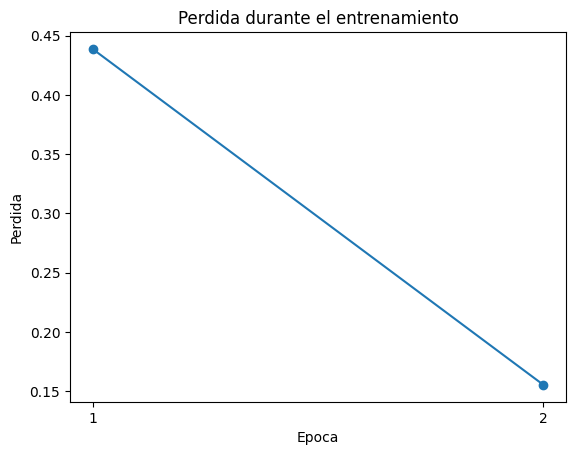

In [9]:
EPOCAS = 2
TASA_APRENDIZAJE = 1e-4

optimizador = AdamW(modelo.parameters(), lr=TASA_APRENDIZAJE)
historial_perdida = []

for epoca in range(EPOCAS):
    modelo.train()
    perdida_total = 0
    correctos = 0
    total = 0

    for i, lote in enumerate(train_loader):
        input_values = lote['input_values'].to(dispositivo)
        etiquetas = lote['labels'].to(dispositivo)

        salidas = modelo(input_values=input_values, labels=etiquetas)
        perdida = salidas.loss

        optimizador.zero_grad()
        perdida.backward()
        optimizador.step()

        perdida_total += perdida.item()
        preds = torch.argmax(salidas.logits, dim=-1)
        correctos += (preds == etiquetas).sum().item()
        total += len(etiquetas)

        if (i + 1) % 10 == 0:
            print(f'  Epoca {epoca+1}, lote {i+1}/{len(train_loader)}, perdida: {perdida.item():.4f}')

    perdida_promedio = perdida_total / len(train_loader)
    exactitud = correctos / total
    historial_perdida.append(perdida_promedio)
    print(f'Epoca {epoca+1}/{EPOCAS} -- Perdida: {perdida_promedio:.4f}, Exactitud: {exactitud:.4f}')
    print()

plt.plot(range(1, EPOCAS + 1), historial_perdida, marker='o')
plt.xlabel('Epoca')
plt.ylabel('Perdida')
plt.title('Perdida durante el entrenamiento')
plt.xticks(range(1, EPOCAS + 1))
plt.show()

<a id="8"></a>
## 8. Evaluación

Se evalúa el modelo sobre el conjunto de validación.

- **Reporte de clasificación**: precisión, recall y F1-score por categoría.
- **Matriz de confusión**: muestra los patrones de error entre categorías.

In [10]:
modelo.eval()
predicciones = []
etiquetas_reales = []

with torch.no_grad():
    for lote in val_loader:
        input_values = lote['input_values'].to(dispositivo)
        salidas = modelo(input_values=input_values)
        preds = torch.argmax(salidas.logits, dim=-1)
        predicciones.extend(preds.cpu().numpy())
        etiquetas_reales.extend(lote['labels'].numpy())

print('=== Reporte de Clasificacion ===')
print(classification_report(etiquetas_reales, predicciones, target_names=CLASES_FINALES))

=== Reporte de Clasificacion ===
              precision    recall  f1-score   support

        agua       0.91      1.00      0.95        40
        aves       1.00      0.94      0.97        32
   mamiferos       0.96      1.00      0.98        48
      viento       1.00      0.50      0.67         8

    accuracy                           0.95       128
   macro avg       0.97      0.86      0.89       128
weighted avg       0.96      0.95      0.95       128



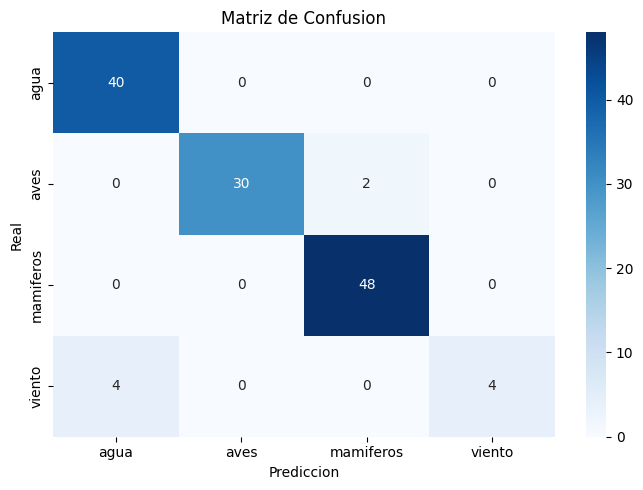

In [11]:
# Matriz de confusion
cm = confusion_matrix(etiquetas_reales, predicciones)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES_FINALES, yticklabels=CLASES_FINALES)
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de Confusion')
plt.tight_layout()
plt.show()

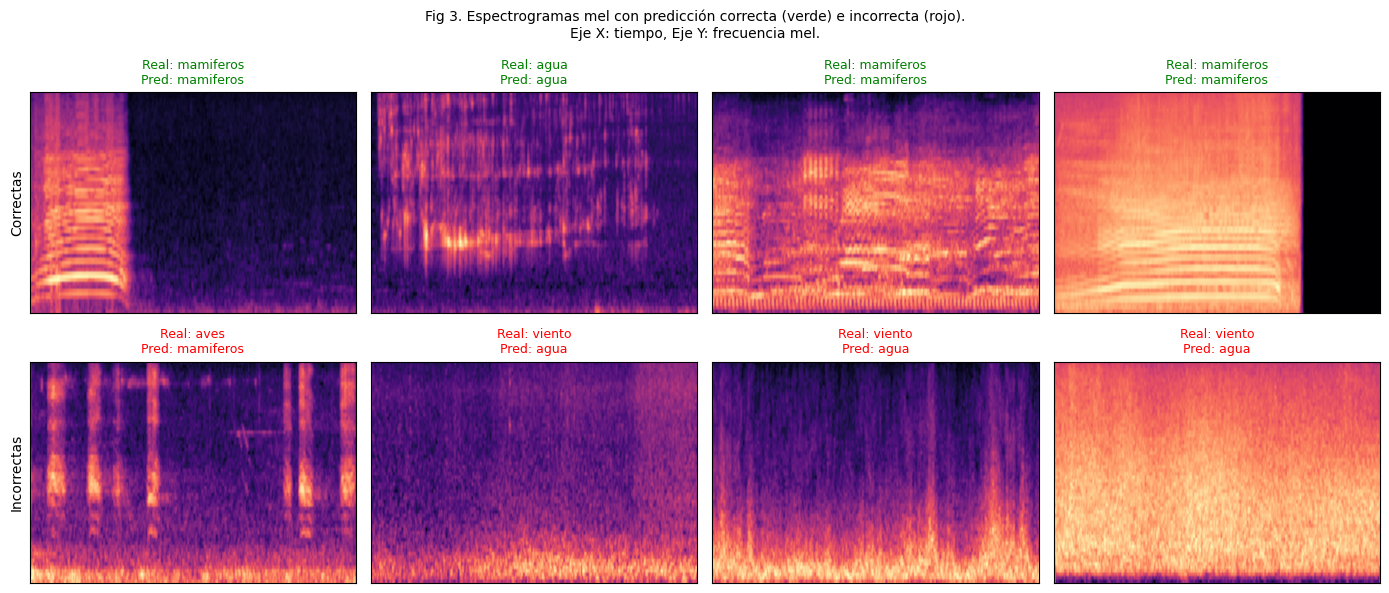

In [13]:
# Fig 3. Espectrogramas con predicción correcta e incorrecta

def get_mel_spec(muestra):
    """Calcula espectrograma mel para visualización."""
    audio = np.array(muestra['audio']['array'], dtype=np.float32)
    sr = muestra['audio']['sampling_rate']
    if sr != 16000:
        audio_t = torch.tensor(audio).unsqueeze(0)
        audio = torchaudio.transforms.Resample(sr, 16000)(audio_t).squeeze(0).numpy()
    audio_t = torch.tensor(audio).unsqueeze(0)
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=16000, n_mels=64, n_fft=1024, hop_length=160
    )(audio_t).squeeze(0)
    return torchaudio.transforms.AmplitudeToDB()(mel).numpy()

# Índices de predicciones correctas e incorrectas
correctos_idx   = [i for i, (r, p) in enumerate(zip(etiquetas_reales, predicciones)) if r == p]
incorrectos_idx = [i for i, (r, p) in enumerate(zip(etiquetas_reales, predicciones)) if r != p]

# Tomar hasta 4 ejemplos de cada tipo
sel_c = correctos_idx[:4]
sel_i = incorrectos_idx[:4]
n_cols = max(len(sel_c), len(sel_i))

fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 6))

for col in range(n_cols):
    for fila, (sel, color) in enumerate([(sel_c, 'green'), (sel_i, 'red')]):
        ax = axes[fila, col]
        if col < len(sel):
            idx = sel[col]
            mel = get_mel_spec(val_4[idx])
            ax.imshow(mel, aspect='auto', origin='lower', cmap='magma')
            real = CLASES_FINALES[etiquetas_reales[idx]]
            pred = CLASES_FINALES[predicciones[idx]]
            ax.set_title(f'Real: {real}\nPred: {pred}', fontsize=9, color=color)
        ax.set_xticks([])
        ax.set_yticks([])

axes[0, 0].set_ylabel('Correctas', fontsize=10)
axes[1, 0].set_ylabel('Incorrectas', fontsize=10)

fig.suptitle(
    'Fig 3. Espectrogramas mel con predicción correcta (verde) e incorrecta (rojo).\n'
    'Eje X: tiempo, Eje Y: frecuencia mel.',
    fontsize=10
)
plt.tight_layout()
plt.show()

<a id="9"></a>
## 9. Conclusiones

Se muestra la exactitud por categoría y se identifican las categorías con mejor y peor rendimiento.

In [14]:
# Exactitud por categoria
exactitudes = cm.diagonal() / cm.sum(axis=1)
tabla_eval = pd.DataFrame({
    'Categoria': CLASES_FINALES,
    'Correctos': cm.diagonal(),
    'Total': cm.sum(axis=1),
    'Exactitud': [f'{e:.2%}' for e in exactitudes]
})
print(tabla_eval.to_string(index=False))
print()

mejor_idx = exactitudes.argmax()
peor_idx = exactitudes.argmin()
print(f'Mejor categoria: {CLASES_FINALES[mejor_idx]} ({exactitudes[mejor_idx]:.2%})')
print(f'Peor categoria:  {CLASES_FINALES[peor_idx]} ({exactitudes[peor_idx]:.2%})')

Categoria  Correctos  Total Exactitud
     agua         40     40   100.00%
     aves         30     32    93.75%
mamiferos         48     48   100.00%
   viento          4      8    50.00%

Mejor categoria: agua (100.00%)
Peor categoria:  viento (50.00%)


### Análisis cualitativo

**Rendimiento general:**
El modelo AST preentrenado en AudioSet muestra transferencia hacia la clasificación
de sonidos naturales en 4 categorías, tras 2 épocas de fine-tuning.

**Categorías con mejor rendimiento:**
Las categorías con características espectrales distintivas obtienen mayor exactitud.
Los sonidos de aves (frecuencias altas, patrones rítmicos) y agua (ruido de banda ancha
con estructura temporal uniforme) tienden a separarse bien en el espacio del espectrograma.

**Categorías con peor rendimiento:**
La categoría viento cuenta con una sola clase ESC50 mapeada, lo que limita la variedad
de muestras. Los sonidos de mamíferos incluyen voces de animales con rangos espectrales
variados, lo que genera confusión con otras categorías.

**Patrones de error:**
La matriz de confusión muestra los pares de categorías más confundidas.
Los errores entre aves y mamíferos son probables, ya que ambos incluyen vocalizaciones
con armónicos similares en el espectrograma.

**Limitaciones:**
- Dos épocas de entrenamiento son insuficientes para que el modelo converja completamente.
- El mapeo de 50 clases a 4 categorías genera desbalance: viento tiene pocas muestras.
- El modelo fue preentrenado en AudioSet con sonidos urbanos y de diversas fuentes,
  no específicamente en sonidos naturales.